In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import pickle

In [4]:
# 1. Load Data
df = pd.read_csv(r'C:\Users\DELL\Desktop\svc\data\raw\train.csv')



C:\Users\DELL\AppData\Local\Temp\ipykernel_2852\173210072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_range', data=df, palette='viridis')


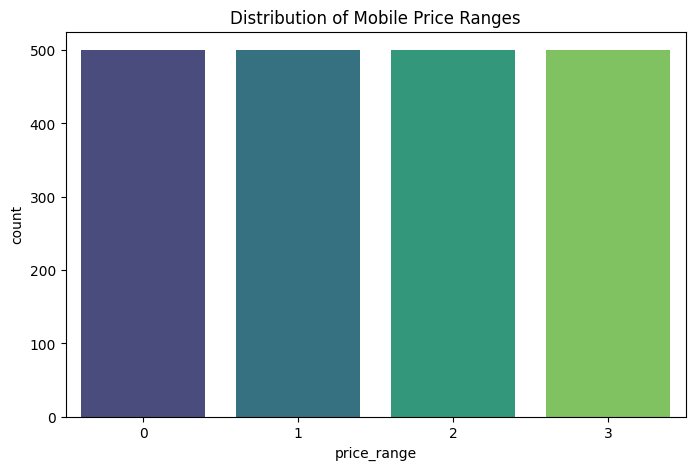

In [5]:
# 2. Exploratory Data Analysis (EDA)
plt.figure(figsize=(8, 5))
sns.countplot(x='price_range', data=df, palette='viridis')
plt.title("Distribution of Mobile Price Ranges")
plt.show()



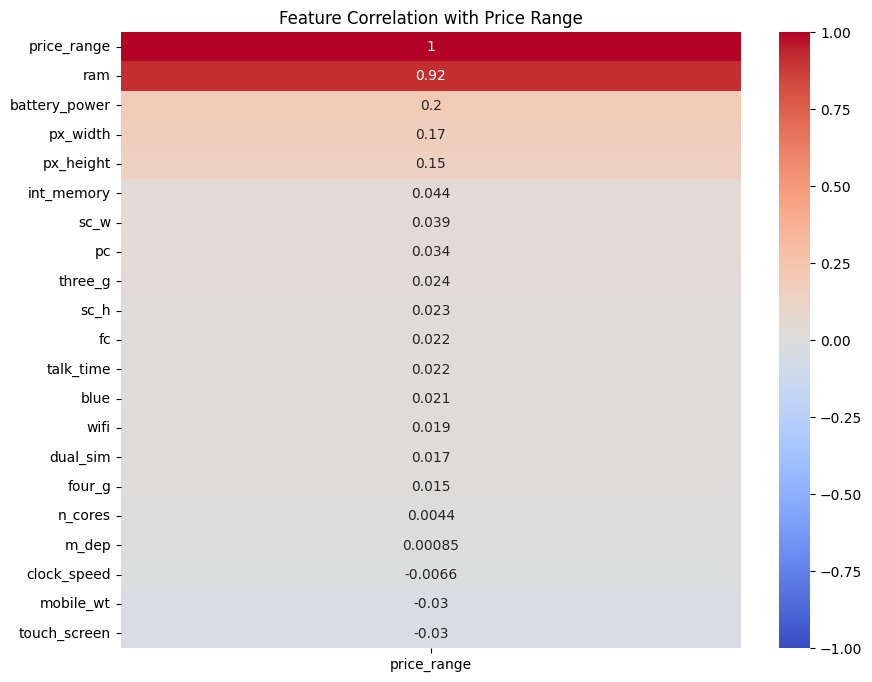

In [6]:
# Find the features most correlated with the price range
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation[['price_range']].sort_values(by='price_range', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation with Price Range")
plt.show()



In [7]:
# 3. Feature Selection
# To keep the Streamlit app simple and elegant, we extract the top 4 most correlated features
features = ['ram', 'battery_power', 'px_width', 'px_height']
X = df[features]
y = df['price_range']



In [8]:
# 4. Train/Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [9]:
# 5. Model Training (Support Vector Classifier)
model = SVC(kernel='linear', C=1.0, random_state=42)
model.fit(X_train_scaled, y_train)



,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
# 6. Evaluation
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))



Accuracy: 96.75%

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       105
           1       0.94      1.00      0.97        91
           2       0.96      0.92      0.94        92
           3       0.97      0.96      0.97       112

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



In [13]:
# 7. Export Artifacts for the Streamlit App
with open(r'C:\Users\DELL\Desktop\svc\models\svc_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(r'C:\Users\DELL\Desktop\svc\models\svc_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)